# Azul fleet exploratory analysis

This notebook explores the Azul fleet sample in a progression that moves from **describing the dataset** to **comparing aircraft fairly**.

The logic is:

1. Understand sample coverage, aircraft mix, and route concentration
2. Group aircraft by observed operational profile
3. Inspect pairwise relationships with scatter plots and correlations
4. Move from raw fuel burn to normalized efficiency metrics
5. Use controlled comparisons to separate mission profile from aircraft effect

The project context emphasizes fuel efficiency as a function of **aircraft type, flight distance, and take-off weight**, so each section builds on the conclusions from the previous one.


In [27]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = "Azul_DataSample.xlsx"
RANDOM_STATE = 42

df = pd.read_excel(DATA_PATH)
df = df.rename(columns={
    "TripFuelBurnTotal [KG]": "fuel_kg",
    "TakeOffWeight  [KG]": "tow_kg",
    "TripTimeSec": "trip_time_sec",
    "GroundDistance [NM]": "distance_nm"
})
df["STDUTC"] = pd.to_datetime(df["STDUTC"])
df["trip_time_min"] = df["trip_time_sec"] / 60
df["route"] = df["DepartureStation"] + "-" + df["ArrivalStation"]

df.head()

,FlightNumber,STDUTC,DepartureStation,ArrivalStation,Equipment,fuel_kg,tow_kg,trip_time_sec,distance_nm,trip_time_min,route
0,4992,2024-05-05 18:20:00,CXJ,VCP,A320,2671,65264,4380,463.10,73.00,CXJ-VCP
1,9002,2024-06-04 16:55:00,VCP,QNS,E1,3143,47891,5340,487.20,89.00,VCP-QNS
2,4942,2024-07-04 09:20:00,VCP,SSA,A320,4389,71041,7020,815.50,117.00,VCP-SSA
3,4942,2024-07-25 09:20:00,VCP,SSA,A320,4546,68618,7620,862.20,127.00,VCP-SSA
4,2601,2024-10-07 06:20:00,MAO,REC,A321,9624,87335,12960,"1,561.10",216.00,MAO-REC


## 1. Basic exploratory analysis

Before comparing aircraft, it is necessary to understand what the sample contains, how flights are distributed across equipment, and whether the route network is concentrated around a few hubs or corridors.


In [28]:
summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "date_min",
        "date_max",
        "missing_values",
        "duplicate_rows",
        "unique_aircraft_types",
        "unique_routes",
        "unique_airports"
    ],
    "value": [
        len(df),
        df.shape[1],
        df["STDUTC"].min(),
        df["STDUTC"].max(),
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        df["Equipment"].nunique(),
        df["route"].nunique(),
        pd.unique(df[["DepartureStation", "ArrivalStation"]].values.ravel("K")).size
    ]
})
summary

,metric,value
0,rows,288337
1,columns,11
2,date_min,2024-01-01 00:05:00
3,date_max,2025-11-15 06:20:00
4,missing_values,0
5,duplicate_rows,0
6,unique_aircraft_types,5
7,unique_routes,419
8,unique_airports,113


In [29]:
numeric_cols = ["fuel_kg", "tow_kg", "trip_time_min", "distance_nm"]
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
fuel_kg,"288,337.00","2,851.71","2,164.01","-37,110.00","1,011.00","2,158.00","4,378.00","16,413.00"
tow_kg,"288,337.00","48,665.17","19,463.35","14,838.00","22,372.00","52,276.00","65,959.00","88,992.00"
trip_time_min,"288,337.00",91.51,49.04,-87.00,54.00,74.00,128.00,485.00
distance_nm,"288,337.00",556.13,390.70,16.00,258.60,385.10,882.00,"3,610.70"


In [30]:
equipment_counts = (
    df["Equipment"]
    .value_counts()
    .rename_axis("equipment")
    .reset_index(name="flights")
)
equipment_counts

,equipment,flights
0,A320,100893
1,ATR,78520
2,E2,50314
3,E1,44816
4,A321,13794


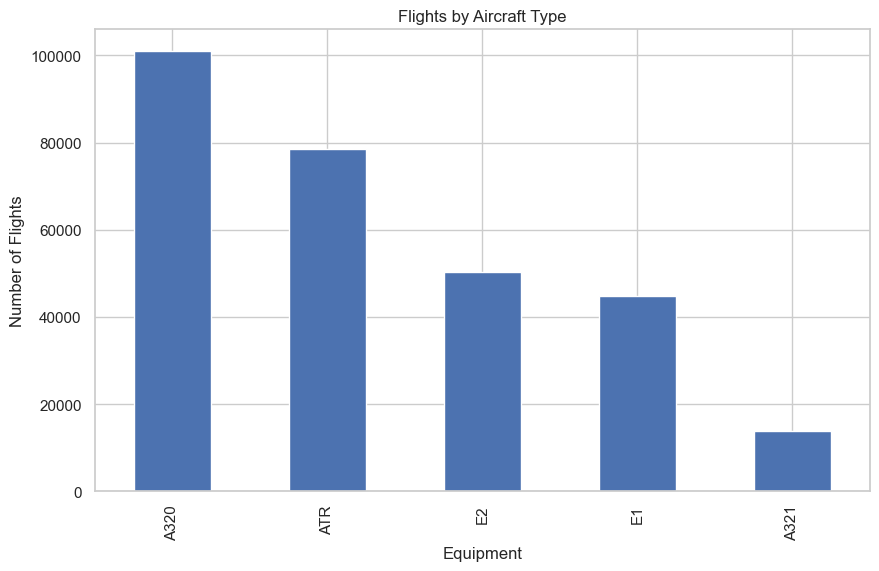

In [31]:
fleet_counts = df["Equipment"].value_counts()

fleet_counts.plot(kind="bar")
plt.title("Flights by Aircraft Type")
plt.ylabel("Number of Flights")
plt.show()

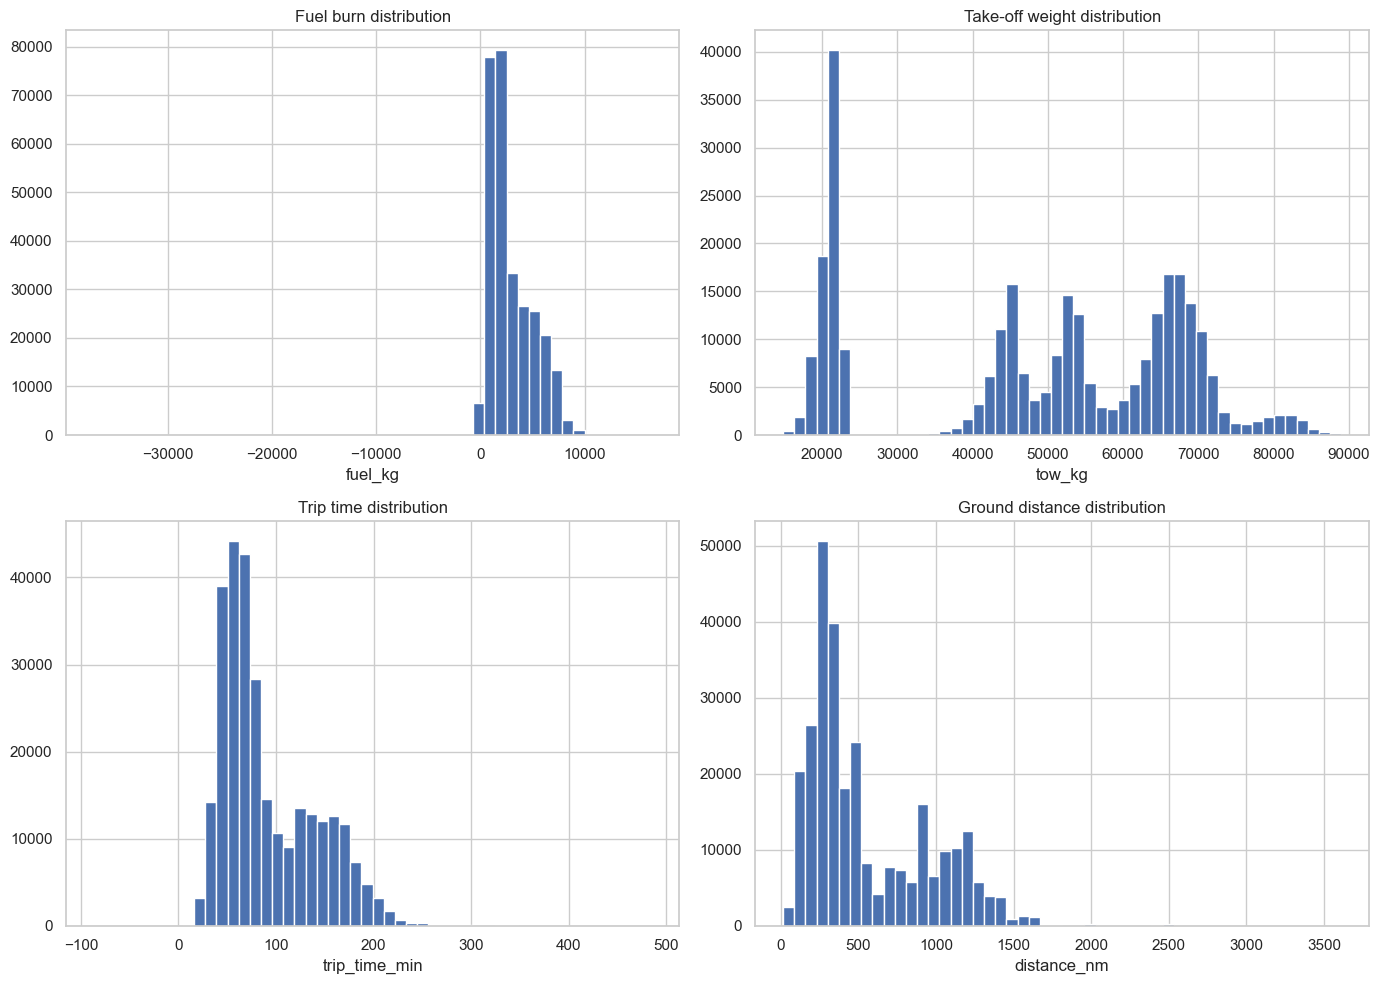

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["fuel_kg"], bins=50)
axes[0, 0].set_title("Fuel burn distribution")
axes[0, 0].set_xlabel("fuel_kg")

axes[0, 1].hist(df["tow_kg"], bins=50)
axes[0, 1].set_title("Take-off weight distribution")
axes[0, 1].set_xlabel("tow_kg")

axes[1, 0].hist(df["trip_time_min"], bins=50)
axes[1, 0].set_title("Trip time distribution")
axes[1, 0].set_xlabel("trip_time_min")

axes[1, 1].hist(df["distance_nm"], bins=50)
axes[1, 1].set_title("Ground distance distribution")
axes[1, 1].set_xlabel("distance_nm")

plt.tight_layout()
plt.show()

In [33]:
equipment_profile = (
    df.groupby("Equipment")
      .agg(
          flights=("FlightNumber", "count"),
          unique_routes=("route", "nunique"),
          tow_mean=("tow_kg", "mean"),
          tow_median=("tow_kg", "median"),
          trip_time_mean_min=("trip_time_min", "mean"),
          trip_time_median_min=("trip_time_min", "median"),
          distance_mean_nm=("distance_nm", "mean"),
          distance_median_nm=("distance_nm", "median"),
          fuel_mean_kg=("fuel_kg", "mean"),
          fuel_median_kg=("fuel_kg", "median")
      )
      .sort_values("distance_mean_nm")
)
equipment_profile

,flights,unique_routes,tow_mean,tow_median,trip_time_mean_min,trip_time_median_min,distance_mean_nm,distance_median_nm,fuel_mean_kg,fuel_median_kg
Equipment,,,,,,,,,,
ATR,78520,220,"20,881.07","21,225.00",62.80,62.00,231.28,231.00,671.55,660.00
E1,44816,269,"43,961.83","44,428.50",60.66,53.00,354.00,295.60,"2,252.26","1,994.00"
E2,50314,260,"52,455.81","52,743.00",78.58,64.00,491.27,382.80,"2,345.78","1,977.00"
A320,100893,294,"66,298.47","66,644.00",123.86,128.00,846.76,889.20,"4,495.91","4,529.00"
A321,13794,96,"79,301.27","80,116.50",165.62,167.00,"1,172.84","1,170.40","7,028.72","7,116.50"


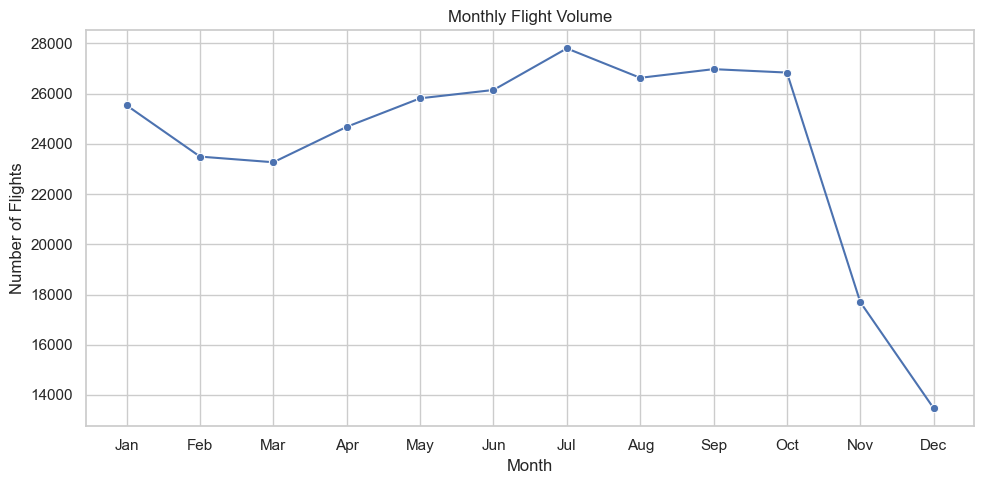

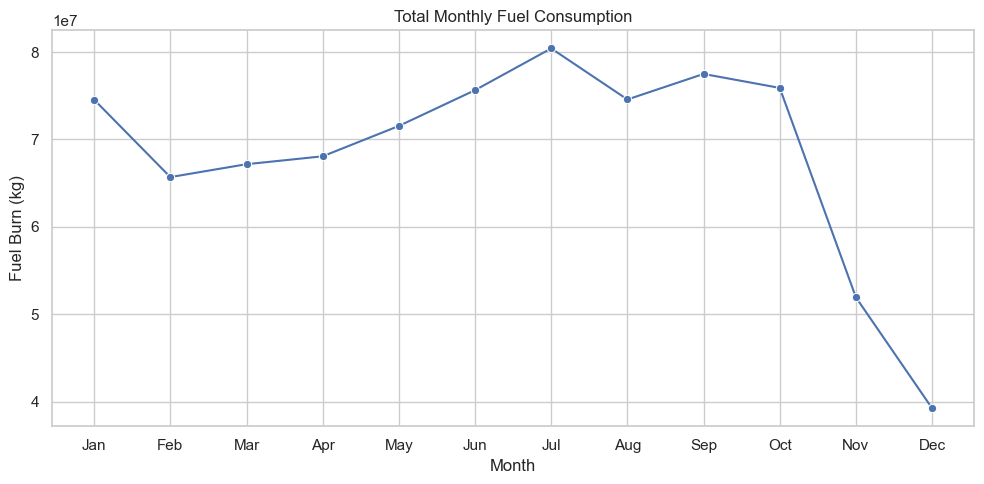

In [34]:
#seasonal variation
df["STDUTC"] = pd.to_datetime(df["STDUTC"])

df["month"] = df["STDUTC"].dt.month
df["month_name"] = df["STDUTC"].dt.strftime("%b")
monthly_flights = (
    df.groupby("month_name")
    .size()
    .reindex(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_flights.index,
    y=monthly_flights.values,
    marker="o"
)

plt.title("Monthly Flight Volume")
plt.xlabel("Month")
plt.ylabel("Number of Flights")

plt.tight_layout()
plt.show()
monthly_flights
monthly_fuel = (
    df.groupby("month_name")["fuel_kg"]
    .sum()
    .reindex(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_fuel.index,
    y=monthly_fuel.values,
    marker="o"
)

plt.title("Total Monthly Fuel Consumption")
plt.xlabel("Month")
plt.ylabel("Fuel Burn (kg)")

plt.tight_layout()
plt.show()


### Network structure and route concentration

After checking basic distributions, the next question is whether the dataset is concentrated around a few airports and recurring routes.  
That matters because later efficiency comparisons become more meaningful when there is route overlap between aircraft types.


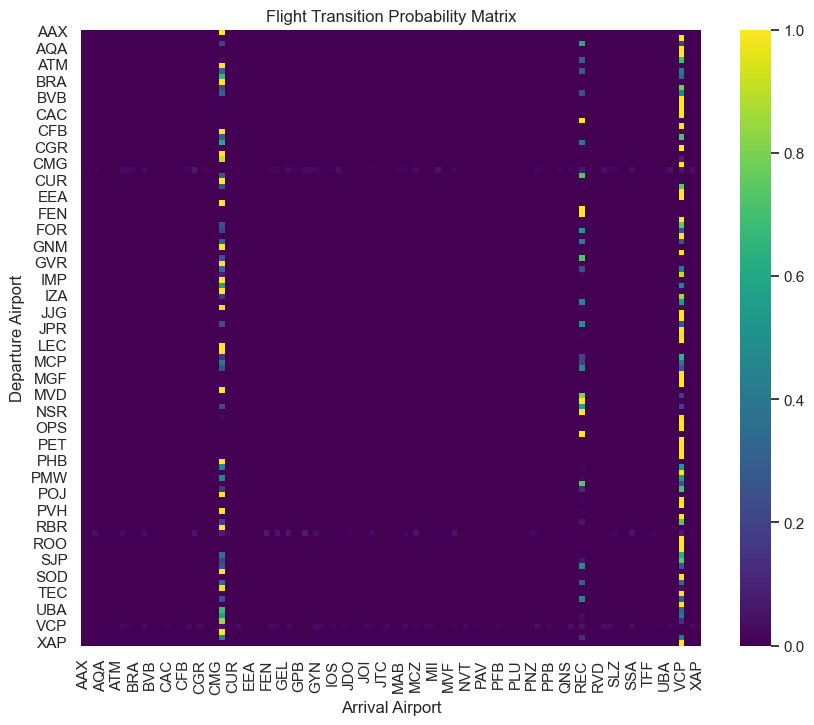

In [35]:
transition_counts = pd.crosstab(
    df["DepartureStation"],
    df["ArrivalStation"]
)
markov_matrix = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    markov_matrix,
    cmap="viridis"
)

plt.title("Flight Transition Probability Matrix")
plt.xlabel("Arrival Airport")
plt.ylabel("Departure Airport")

plt.show()


In [36]:
#establishing evidence for the hubs using Markov Matrix
P = markov_matrix.values

eigvals, eigvecs = np.linalg.eig(P.T)

stationary = np.real(eigvecs[:,np.isclose(eigvals,1)])

stationary = stationary / stationary.sum()

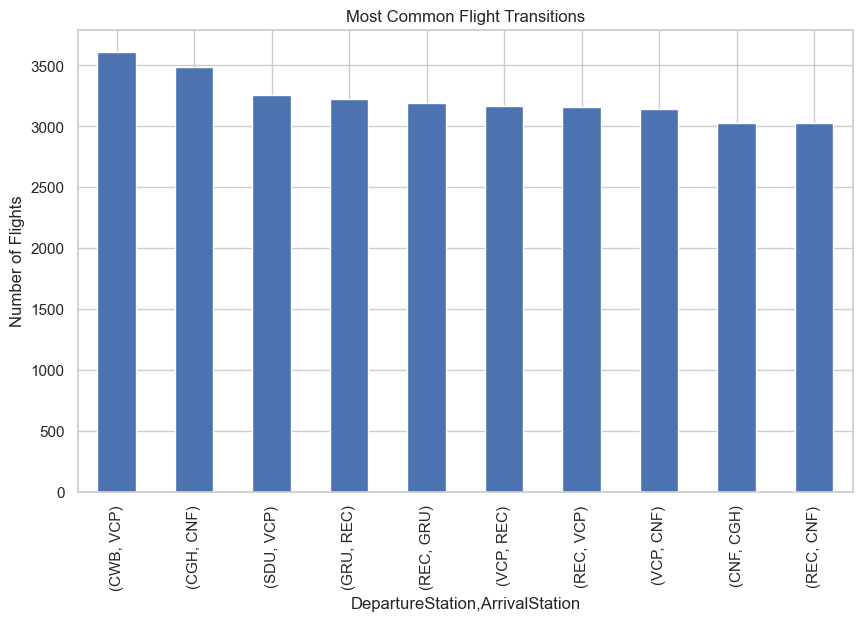

In [37]:
top_routes = transition_counts.stack().sort_values(ascending=False).head(10)

top_routes.plot(kind="bar")
plt.title("Most Common Flight Transitions")
plt.ylabel("Number of Flights")
plt.show()

## 2. Correlation analysis

With the visual patterns established, this section quantifies them using **Pearson** and **Spearman** correlations on the full dataset and within each equipment family.


In [38]:
pearson_corr = df[numeric_cols].corr(method="pearson")
spearman_corr = df[numeric_cols].corr(method="spearman")

print("Pearson correlation")
display(pearson_corr)

print("\nSpearman correlation")
display(spearman_corr)

Pearson correlation


,fuel_kg,tow_kg,trip_time_min,distance_nm
fuel_kg,1.00,0.83,0.92,0.97
tow_kg,0.83,1.00,0.62,0.74
trip_time_min,0.92,0.62,1.00,0.97
distance_nm,0.97,0.74,0.97,1.00



Spearman correlation


,fuel_kg,tow_kg,trip_time_min,distance_nm
fuel_kg,1.00,0.90,0.83,0.96
tow_kg,0.90,1.00,0.67,0.83
trip_time_min,0.83,0.67,1.00,0.93
distance_nm,0.96,0.83,0.93,1.00


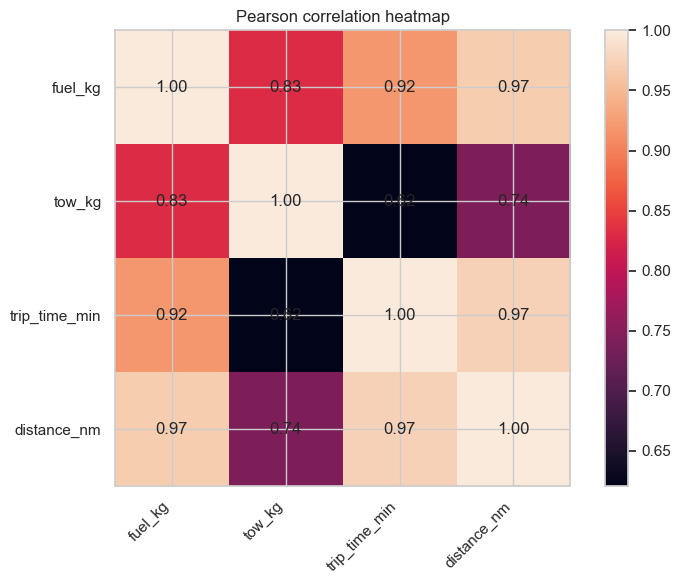

In [39]:
def plot_corr_heatmap(corr_df, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr_df.values)
    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_df.index)
    ax.set_title(title)

    for i in range(corr_df.shape[0]):
        for j in range(corr_df.shape[1]):
            ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

plot_corr_heatmap(pearson_corr, "Pearson correlation heatmap")

In [40]:
fuel_corr_by_equipment = []
for equipment, g in df.groupby("Equipment"):
    row = {
        "Equipment": equipment,
        "fuel_vs_tow": g["fuel_kg"].corr(g["tow_kg"]),
        "fuel_vs_trip_time": g["fuel_kg"].corr(g["trip_time_min"]),
        "fuel_vs_distance": g["fuel_kg"].corr(g["distance_nm"]),
    }
    fuel_corr_by_equipment.append(row)

fuel_corr_by_equipment = pd.DataFrame(fuel_corr_by_equipment).sort_values("Equipment")
fuel_corr_by_equipment

,Equipment,fuel_vs_tow,fuel_vs_trip_time,fuel_vs_distance
0,A320,0.64,0.99,0.98
1,A321,0.72,0.96,0.94
2,ATR,0.33,0.98,0.98
3,E1,0.35,0.98,0.98
4,E2,0.51,0.95,0.95


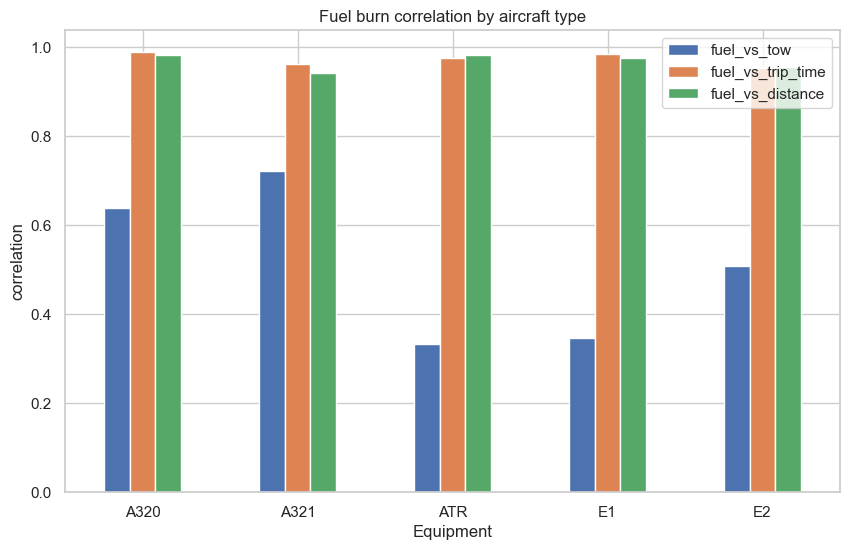

In [41]:
fuel_corr_plot = fuel_corr_by_equipment.set_index("Equipment")

fuel_corr_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Fuel burn correlation by aircraft type")
plt.ylabel("correlation")
plt.xticks(rotation=0)
plt.show()

### Interpreting the EDA

### What seems most correlated

On the full dataset, the strongest expected relationships should be:

1. **distance_nm ↔ trip_time_min**
2. **fuel_kg ↔ distance_nm**
3. **fuel_kg ↔ trip_time_min**

**tow_kg** should also correlate with **fuel_kg**, but usually less strongly than distance and time because different aircraft families fly different routes.

### What to watch out for

- **Distance** and **trip time** are probably close substitutes in a model, so using both in the same linear model may create multicollinearity.
- The overall correlation can be inflated by aircraft-family differences. That is why checking correlations **within each equipment type** is important.

## 3. Scatter plots with trend lines

After defining comparable aircraft groups, the next step is to inspect the main operational relationships visually.  
The sequence starts with **distance vs trip time**, then moves to how **fuel burn** changes with time and weight.

To keep plots readable, we used a sample for the scatter points and computed the trend line from the same sample.


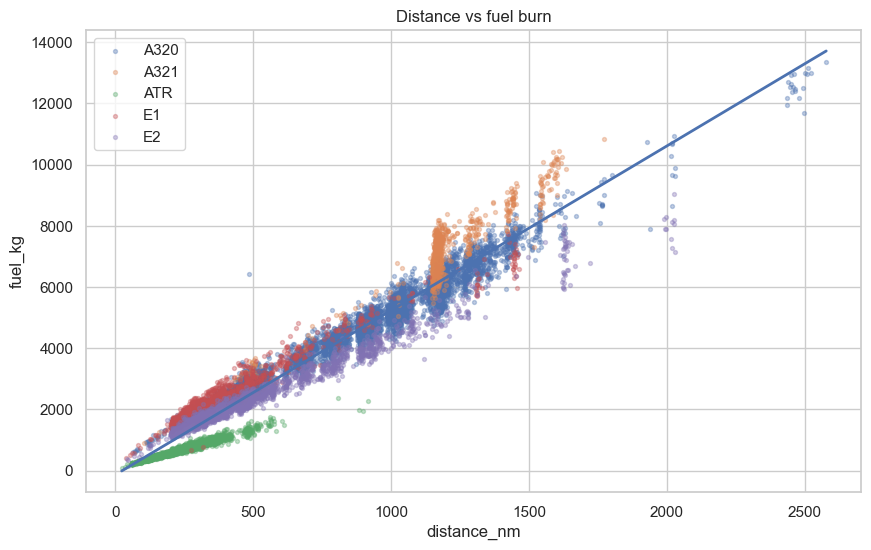

In [42]:
plot_sample = df.sample(n=min(15000, len(df)), random_state=RANDOM_STATE).copy()

def scatter_with_trend(data, x, y, title, by_equipment=False):
    plt.figure(figsize=(10, 6))

    if by_equipment:
        for equipment, g in data.groupby("Equipment"):
            plt.scatter(g[x], g[y], s=8, alpha=0.35, label=equipment)
        plt.legend()
    else:
        plt.scatter(data[x], data[y], s=8, alpha=0.35)

    coef = np.polyfit(data[x], data[y], 1)
    x_line = np.linspace(data[x].min(), data[x].max(), 200)
    y_line = coef[0] * x_line + coef[1]
    plt.plot(x_line, y_line, linewidth=2)

    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

scatter_with_trend(plot_sample, "distance_nm", "fuel_kg", "Distance vs fuel burn", by_equipment=True)

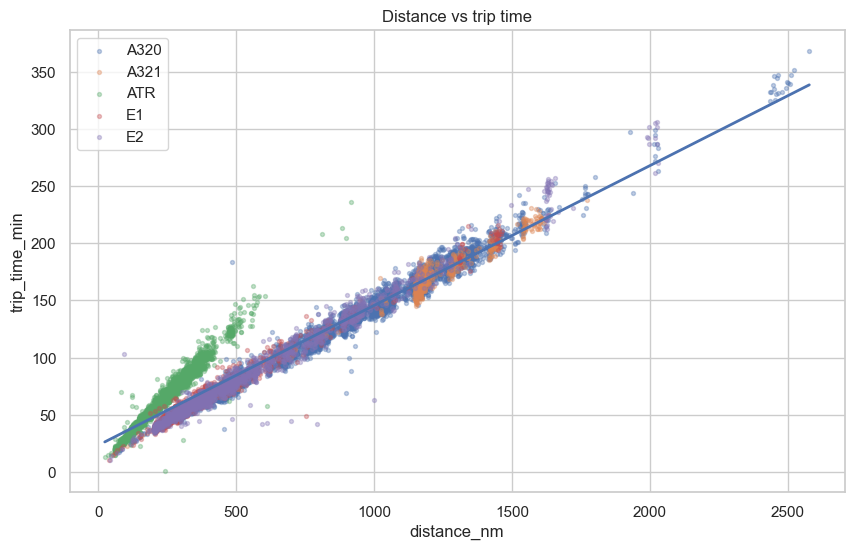

In [43]:
scatter_with_trend(plot_sample, "distance_nm", "trip_time_min", "Distance vs trip time", by_equipment=True)

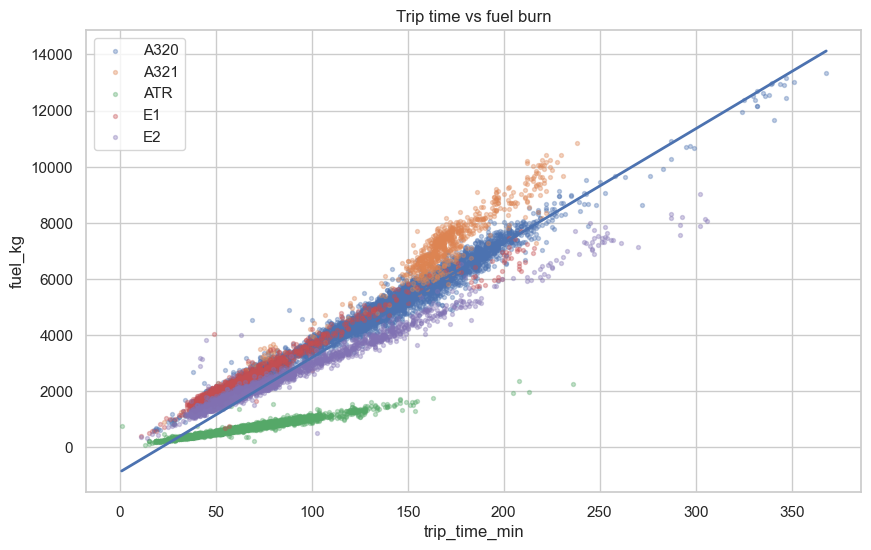

In [44]:
scatter_with_trend(plot_sample, "trip_time_min", "fuel_kg", "Trip time vs fuel burn", by_equipment=True)

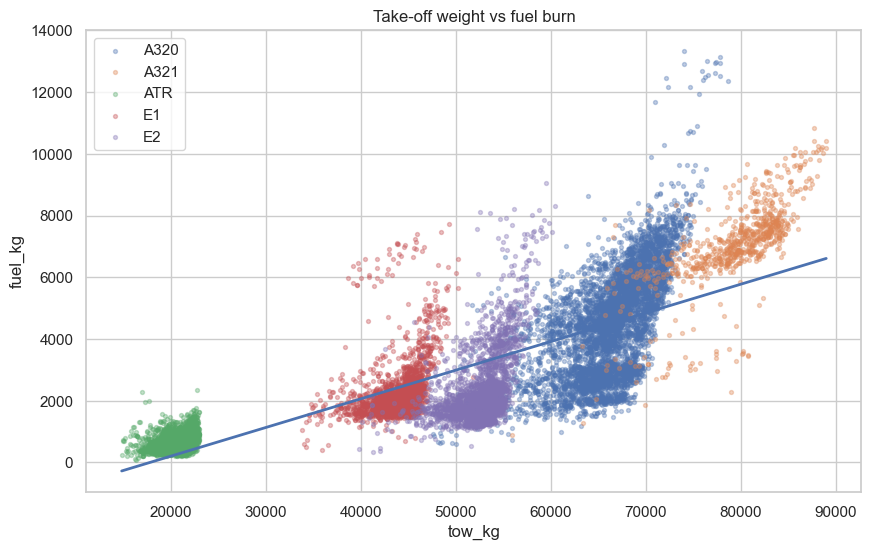

In [45]:
scatter_with_trend(plot_sample, "tow_kg", "fuel_kg", "Take-off weight vs fuel burn", by_equipment=True)

### First visual takeaways

The scatter plots provide the first visual evidence for what should be tested next with correlations:

- **Distance and trip time** should be very strongly related
- **Fuel burn** should rise strongly with both **distance** and **trip time**
- **Take-off weight** should also matter, but likely with more dispersion because route length and aircraft family influence fuel burn at the same time
- The colored scatter plots help show whether the same global trend holds within each aircraft family


### Equipment-level versions of the section 3 charts

The next cell recreates the three pairwise plots separately for each equipment type and adds a smooth tendency curve. This makes it easier to compare the operational profile of each aircraft family without the overlap from the full fleet view.

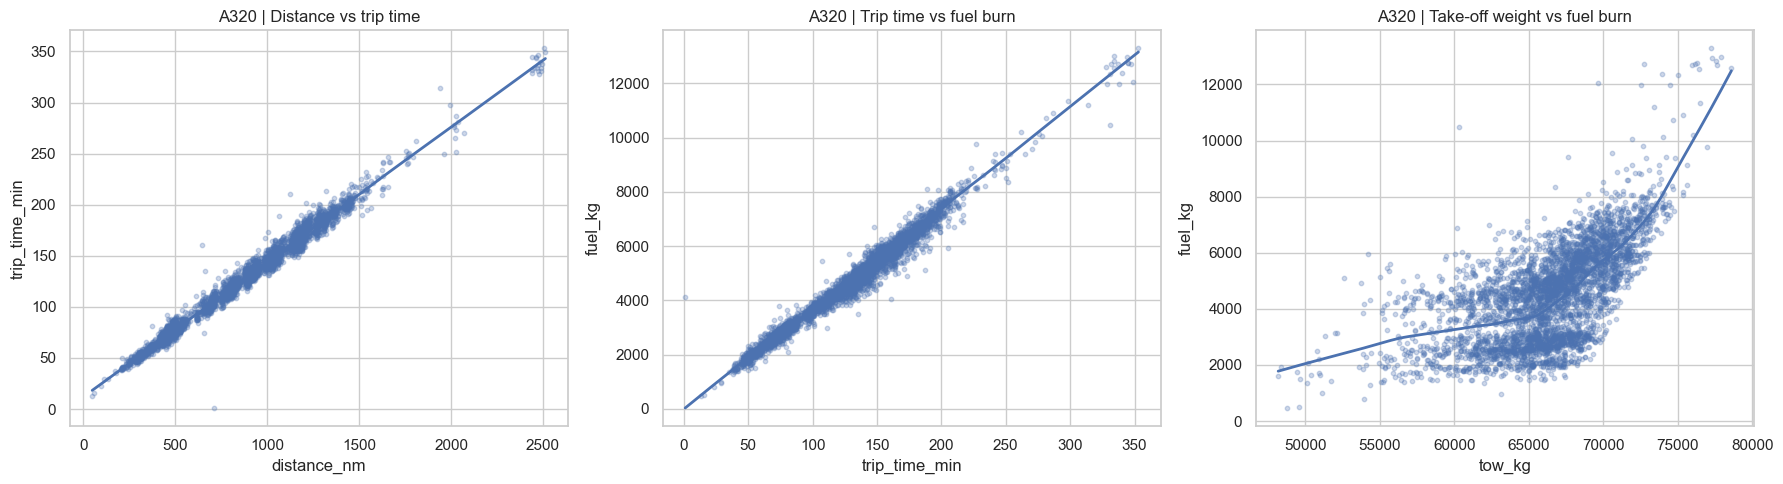

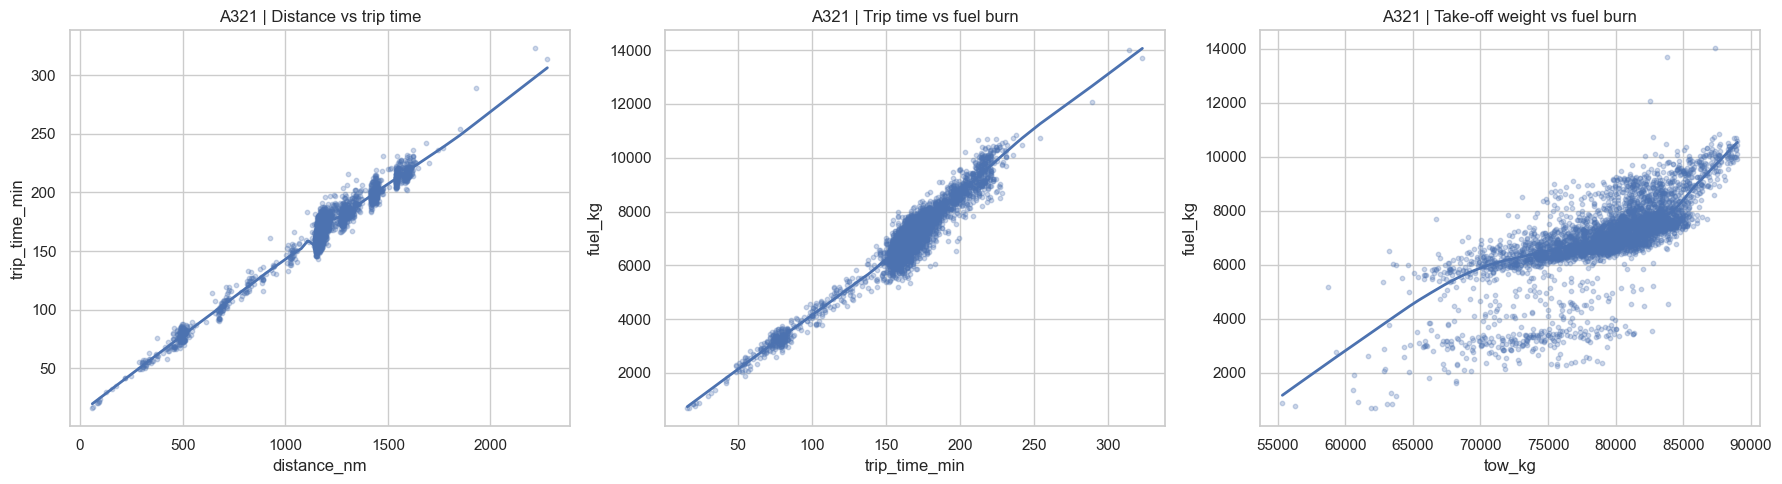

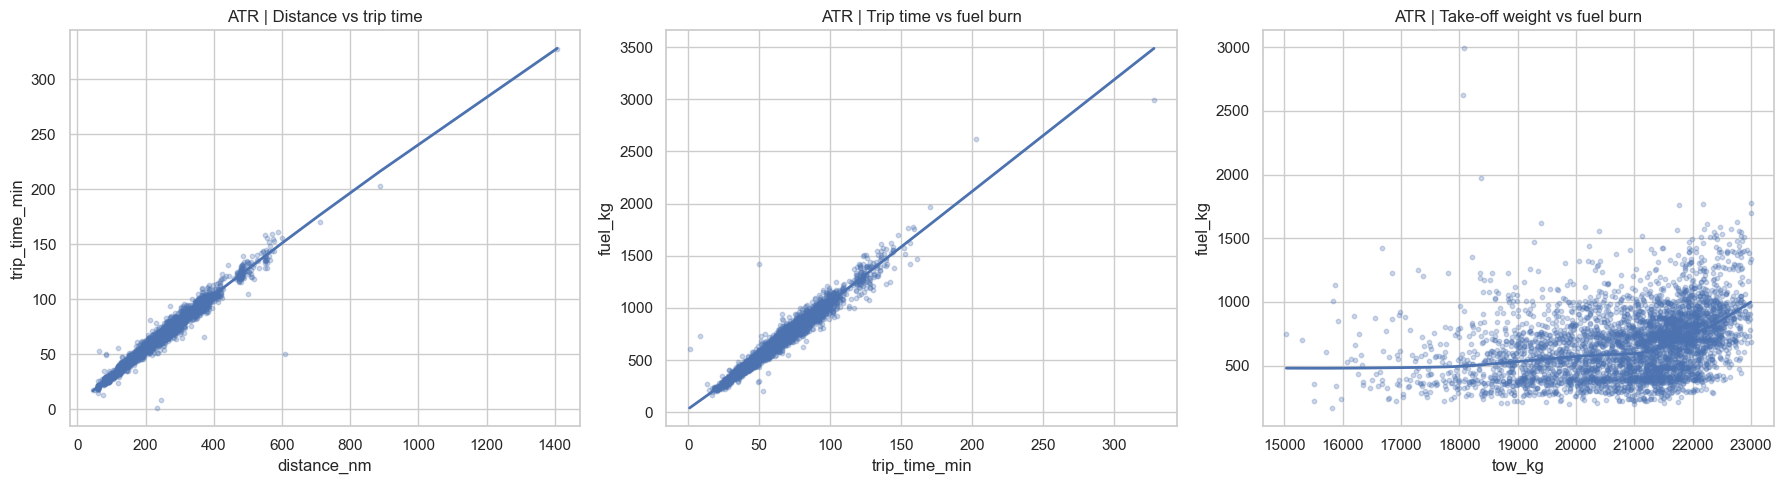

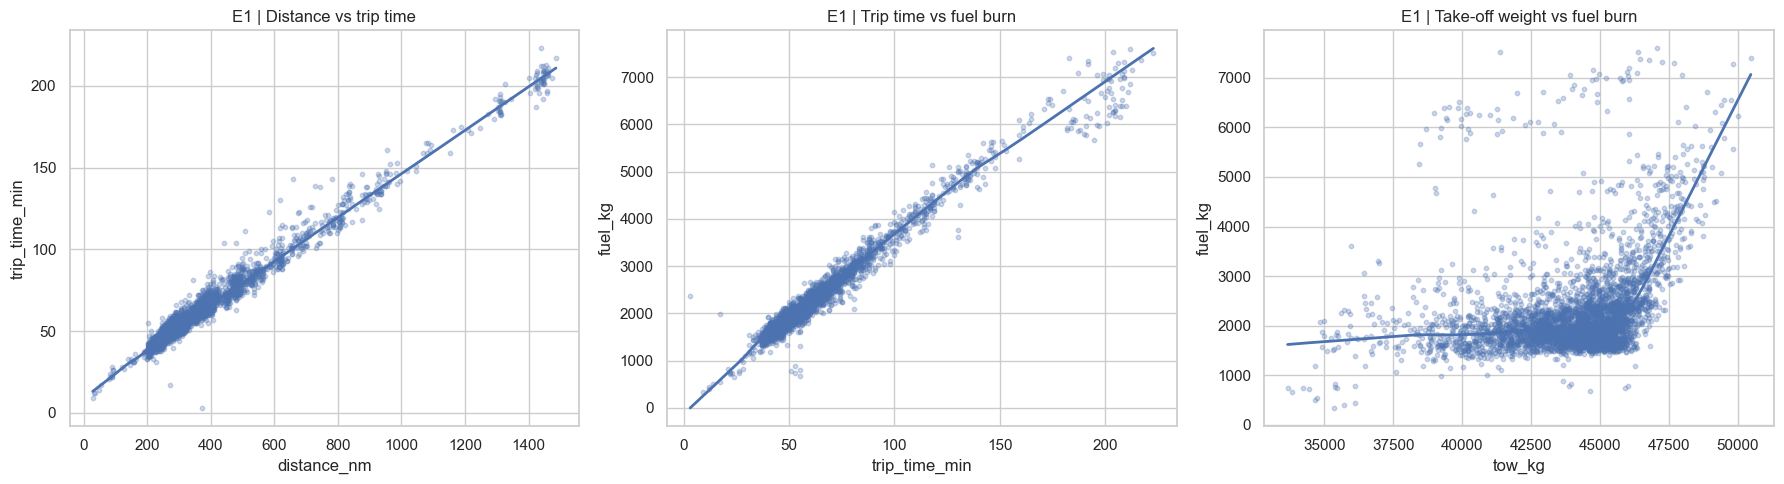

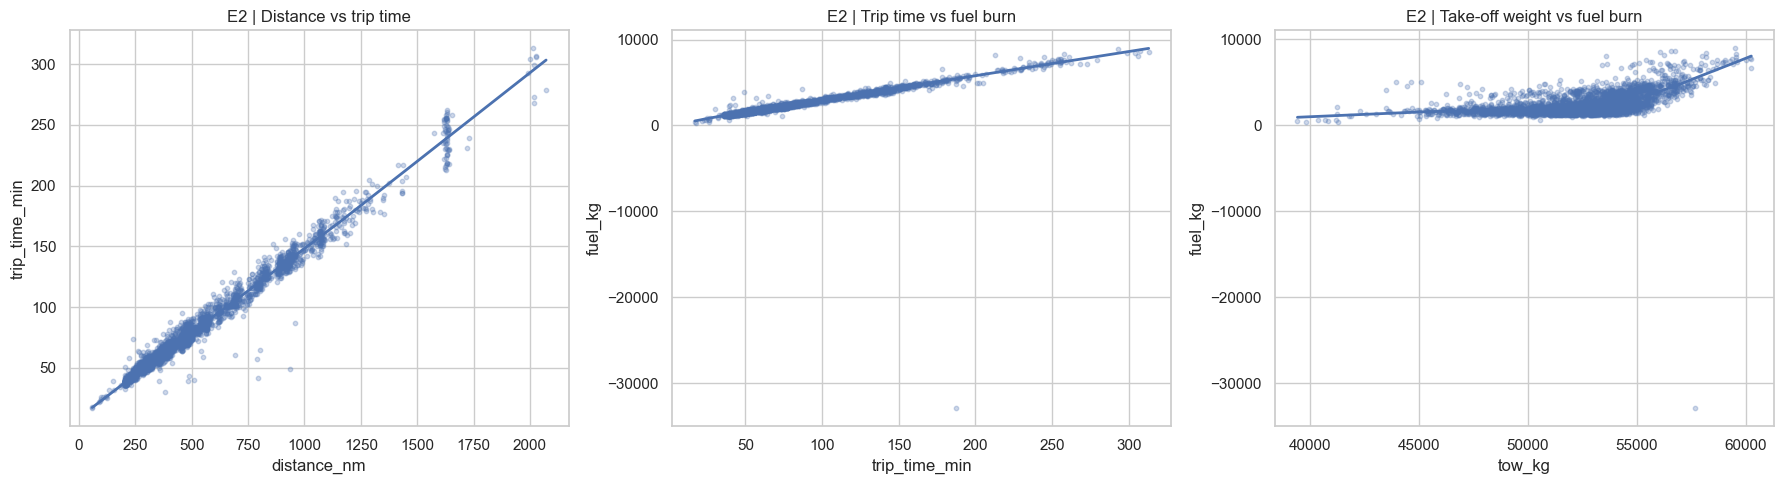

In [46]:
from statsmodels.nonparametric.smoothers_lowess import lowess

section3_pairs = [
    ("distance_nm", "trip_time_min", "Distance vs trip time"),
    ("trip_time_min", "fuel_kg", "Trip time vs fuel burn"),
    ("tow_kg", "fuel_kg", "Take-off weight vs fuel burn")
]

plot_vars = sorted({col for x, y, _ in section3_pairs for col in [x, y]})
plot_base = df.dropna(subset=plot_vars + ["Equipment"]).copy()


def plot_section3_by_equipment(data, equipment, pairs, sample_size=4000, frac=0.22):
    g = data[data["Equipment"] == equipment].copy()
    if len(g) > sample_size:
        g = g.sample(sample_size, random_state=RANDOM_STATE)

    fig, axes = plt.subplots(1, len(pairs), figsize=(18, 5))

    for ax, (x, y, title) in zip(axes, pairs):
        g2 = g[[x, y]].dropna().sort_values(x)
        ax.scatter(g2[x], g2[y], s=10, alpha=0.28)

        if len(g2) >= 50 and g2[x].nunique() > 10:
            smoothed = lowess(g2[y], g2[x], frac=frac, return_sorted=True)
            ax.plot(smoothed[:, 0], smoothed[:, 1], linewidth=2)

        ax.set_title(f"{equipment} | {title}")
        ax.set_xlabel(x)
        ax.set_ylabel(y)

    plt.tight_layout()
    plt.show()


for equipment in sorted(plot_base["Equipment"].unique()):
    plot_section3_by_equipment(plot_base, equipment, section3_pairs)


### Observed optimal operating windows by aircraft

To make "optimal conditions" measurable from the sample, the next cell defines a practical sweet spot for each aircraft as the **best 25% of flights in fuel burn per nautical mile** within that equipment type. This is not a manufacturer performance limit. It is the most efficient operating window observed in this dataset.

The table reports the median sweet-spot conditions and the interquartile range for distance, trip time, and take-off weight.

In [47]:
optimal_base = df[
    (df["fuel_kg"] > 0) &
    (df["trip_time_min"] > 0) &
    (df["distance_nm"] > 0) &
    (df["tow_kg"] > 0)
].copy()

optimal_base["fuel_per_nm"] = optimal_base["fuel_kg"] / optimal_base["distance_nm"]
optimal_base["fuel_per_min"] = optimal_base["fuel_kg"] / optimal_base["trip_time_min"]

optimal_rows = []

for equipment, g in optimal_base.groupby("Equipment"):
    threshold = g["fuel_per_nm"].quantile(0.25)
    best = g[g["fuel_per_nm"] <= threshold].copy()

    optimal_rows.append({
        "Equipment": equipment,
        "Flights in sample": len(g),
        "Sweet spot distance (median NM)": round(best["distance_nm"].median(), 1),
        "Distance window (IQR NM)": f"{best['distance_nm'].quantile(0.25):.1f} to {best['distance_nm'].quantile(0.75):.1f}",
        "Sweet spot trip time (median min)": round(best["trip_time_min"].median(), 1),
        "Trip time window (IQR min)": f"{best['trip_time_min'].quantile(0.25):.1f} to {best['trip_time_min'].quantile(0.75):.1f}",
        "Sweet spot TOW (median kg)": round(best["tow_kg"].median(), 1),
        "TOW window (IQR kg)": f"{best['tow_kg'].quantile(0.25):.1f} to {best['tow_kg'].quantile(0.75):.1f}",
        "Median fuel per NM in sweet spot": round(best["fuel_per_nm"].median(), 2),
        "Median fuel per min in sweet spot": round(best["fuel_per_min"].median(), 2),
        "Improvement vs typical fuel per NM": f"{(1 - best['fuel_per_nm'].median() / g['fuel_per_nm'].median()) * 100:.1f}%"
    })

optimal_conditions = pd.DataFrame(optimal_rows).sort_values("Median fuel per NM in sweet spot")
optimal_conditions


,Equipment,Flights in sample,Sweet spot distance (median NM),Distance window (IQR NM),Sweet spot trip time (median min),Trip time window (IQR min),Sweet spot TOW (median kg),TOW window (IQR kg),Median fuel per NM in sweet spot,Median fuel per min in sweet spot,Improvement vs typical fuel per NM
2,ATR,78520,288.00,241.0 to 355.0,75.00,63.0 to 91.0,"20,639.00",19325.5 to 21634.0,2.69,10.22,9.1%
4,E2,50309,790.00,513.5 to 949.6,116.00,78.0 to 142.0,"53,399.00",51292.2 to 55182.0,4.36,28.82,12.5%
0,A320,100893,"1,033.00",899.3 to 1186.3,145.00,128.0 to 166.0,"65,568.50",62659.5 to 67665.0,4.88,34.72,9.3%
1,A321,13794,"1,167.10",1154.2 to 1179.1,160.00,156.0 to 166.0,"75,770.00",72660.0 to 78130.0,5.50,39.94,8.4%
3,E1,44816,465.60,364.7 to 649.5,73.00,60.0 to 99.0,"44,283.00",41644.8 to 46011.5,5.80,36.19,13.1%


### Quick interpretation of the observed sweet spots

ATR is the most fuel-efficient family per nautical mile in the sample and performs best on short sectors around **241 to 355 NM**. E2 is the next strongest jet profile and looks most efficient on medium sectors around **514 to 950 NM**. A320 reaches its best window on medium-long sectors around **899 to 1,186 NM**.

A321 also looks best on long sectors, but in this sample it is concentrated in a much narrower mission profile around **1,154 to 1,179 NM**. E1 improves materially on longer missions than its median profile, with the best window concentrated around **365 to 649 NM**.

Operationally, the pattern suggests a stage-length ladder: **ATR for short-haul, E1 for short-medium, E2 for medium, and A320/A321 for medium-long to long sectors**. The exact assignment should still be validated route by route, especially where airport constraints, payload, or network timing matter.

### Scatter plots by equipment with the joint sweet spot highlighted

The sweet-spot table above reports separate IQR windows for **distance**, **trip time**, and **take-off weight** inside the most fuel-efficient quartile of flights for each aircraft type.

The next cells apply a stricter joint rule for each equipment family: a flight is tagged as being inside the sweet spot only when it falls inside **all three windows at the same time** for its own aircraft model.

The next plots will visually highlight the ones that belong to that model's joint sweet-spot window.


In [48]:
sweet_spot_bounds = []

for equipment, g in optimal_base.groupby("Equipment"):
    threshold = g["fuel_per_nm"].quantile(0.25)
    best = g[g["fuel_per_nm"] <= threshold].copy()

    sweet_spot_bounds.append({
        "Equipment": equipment,
        "distance_q1": best["distance_nm"].quantile(0.25),
        "distance_q3": best["distance_nm"].quantile(0.75),
        "trip_time_q1": best["trip_time_min"].quantile(0.25),
        "trip_time_q3": best["trip_time_min"].quantile(0.75),
        "tow_q1": best["tow_kg"].quantile(0.25),
        "tow_q3": best["tow_kg"].quantile(0.75),
        "best_quartile_flights": len(best),
        "total_equipment_flights": len(g)
    })

sweet_spot_bounds = pd.DataFrame(sweet_spot_bounds)

sweet_spot_joint = optimal_base.merge(sweet_spot_bounds, on="Equipment", how="left")

sweet_spot_joint["is_joint_sweet_spot"] = (
    sweet_spot_joint["distance_nm"].between(sweet_spot_joint["distance_q1"], sweet_spot_joint["distance_q3"]) &
    sweet_spot_joint["trip_time_min"].between(sweet_spot_joint["trip_time_q1"], sweet_spot_joint["trip_time_q3"]) &
    sweet_spot_joint["tow_kg"].between(sweet_spot_joint["tow_q1"], sweet_spot_joint["tow_q3"])
)

joint_sweet_spot_summary = (
    sweet_spot_joint[sweet_spot_joint["is_joint_sweet_spot"]]
    .groupby("Equipment")
    .agg(
        flights_in_joint_sweet_spot=("FlightNumber", "count"),
        median_distance_nm=("distance_nm", "median"),
        median_trip_time_min=("trip_time_min", "median"),
        median_tow_kg=("tow_kg", "median"),
        median_fuel_per_nm=("fuel_per_nm", "median")
    )
    .reset_index()
    .merge(
        sweet_spot_bounds[["Equipment", "best_quartile_flights", "total_equipment_flights"]],
        on="Equipment",
        how="right"
    )
)

joint_sweet_spot_summary["flights_in_joint_sweet_spot"] = (
    joint_sweet_spot_summary["flights_in_joint_sweet_spot"].fillna(0).astype(int)
)

joint_sweet_spot_summary["share_of_best_quartile_%"] = (
    joint_sweet_spot_summary["flights_in_joint_sweet_spot"] /
    joint_sweet_spot_summary["best_quartile_flights"] * 100
).round(1)

joint_sweet_spot_summary["share_of_total_equipment_%"] = (
    joint_sweet_spot_summary["flights_in_joint_sweet_spot"] /
    joint_sweet_spot_summary["total_equipment_flights"] * 100
).round(1)

joint_sweet_spot_summary.sort_values("median_distance_nm")


,Equipment,flights_in_joint_sweet_spot,median_distance_nm,median_trip_time_min,median_tow_kg,median_fuel_per_nm,best_quartile_flights,total_equipment_flights,share_of_best_quartile_%,share_of_total_equipment_%
2,ATR,10908,274.00,73.00,"21,043.50",2.82,19631,78520,55.60,13.90
3,E1,5830,405.10,69.00,"44,813.00",6.12,11204,44816,52.00,13.00
4,E2,6307,693.30,106.00,"53,705.00",4.52,12578,50309,50.10,12.50
0,A320,11072,"1,021.80",144.00,"66,080.00",5.00,25224,100893,43.90,11.00
1,A321,897,"1,166.70",161.00,"76,217.00",5.57,3449,13794,26.00,6.50


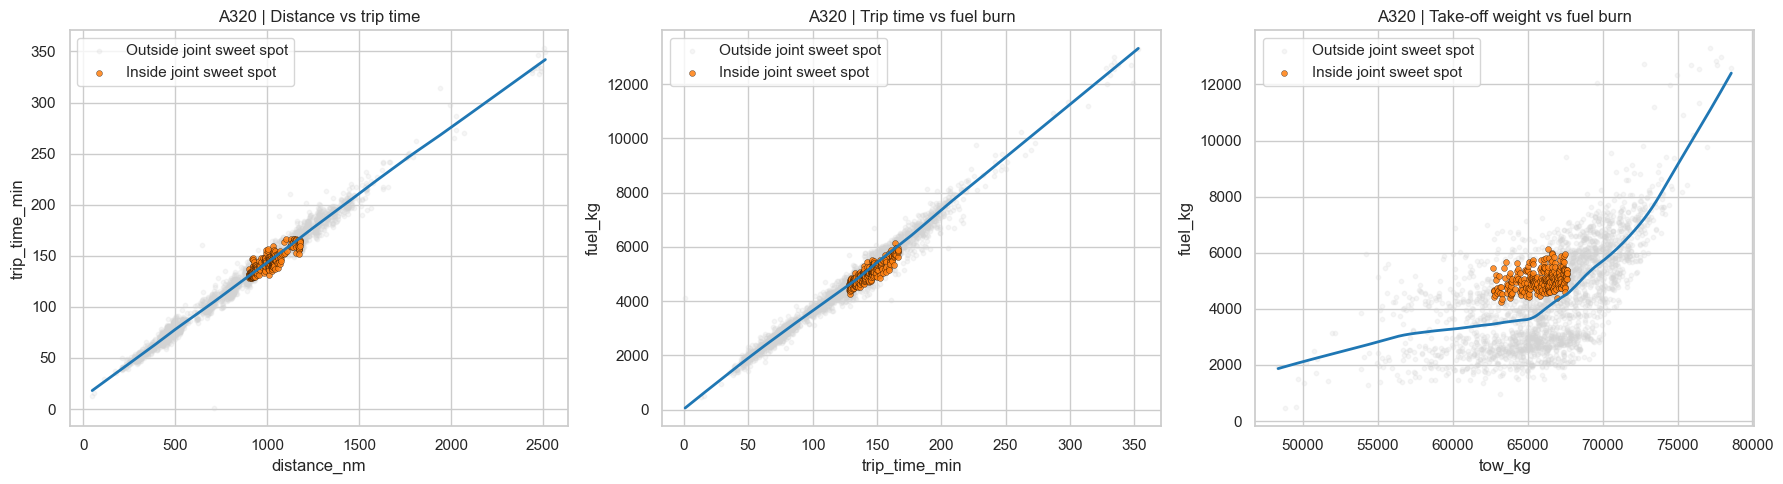

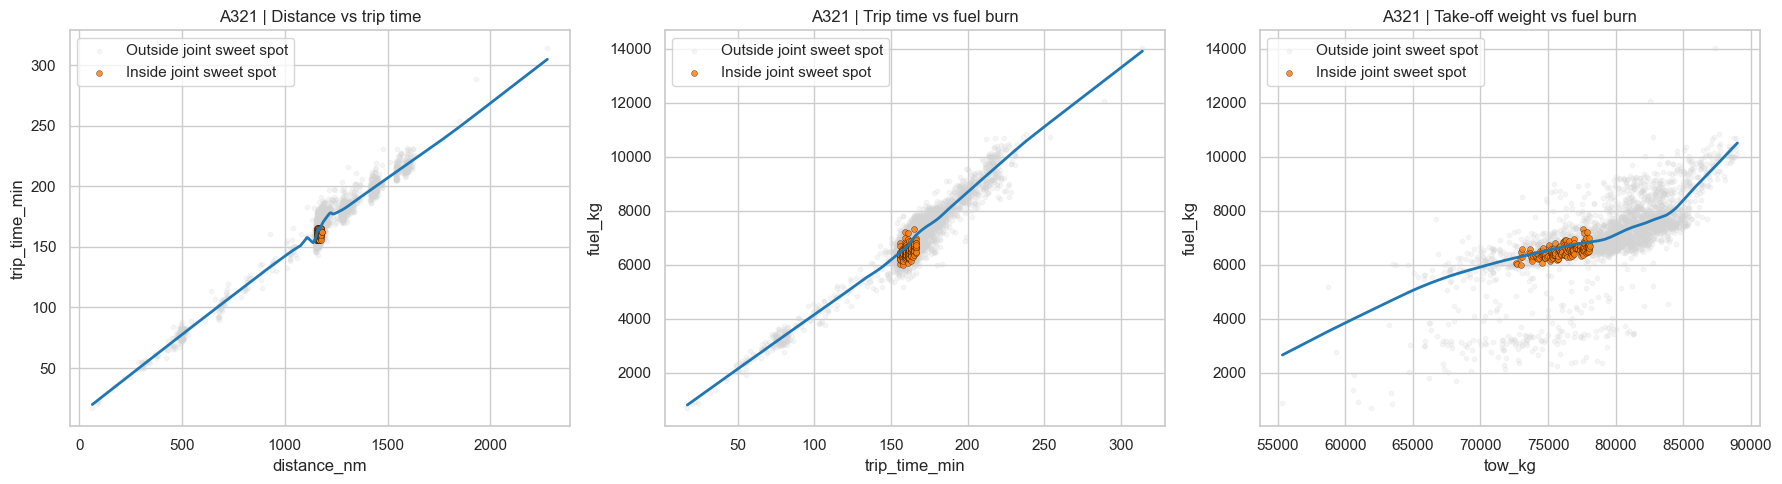

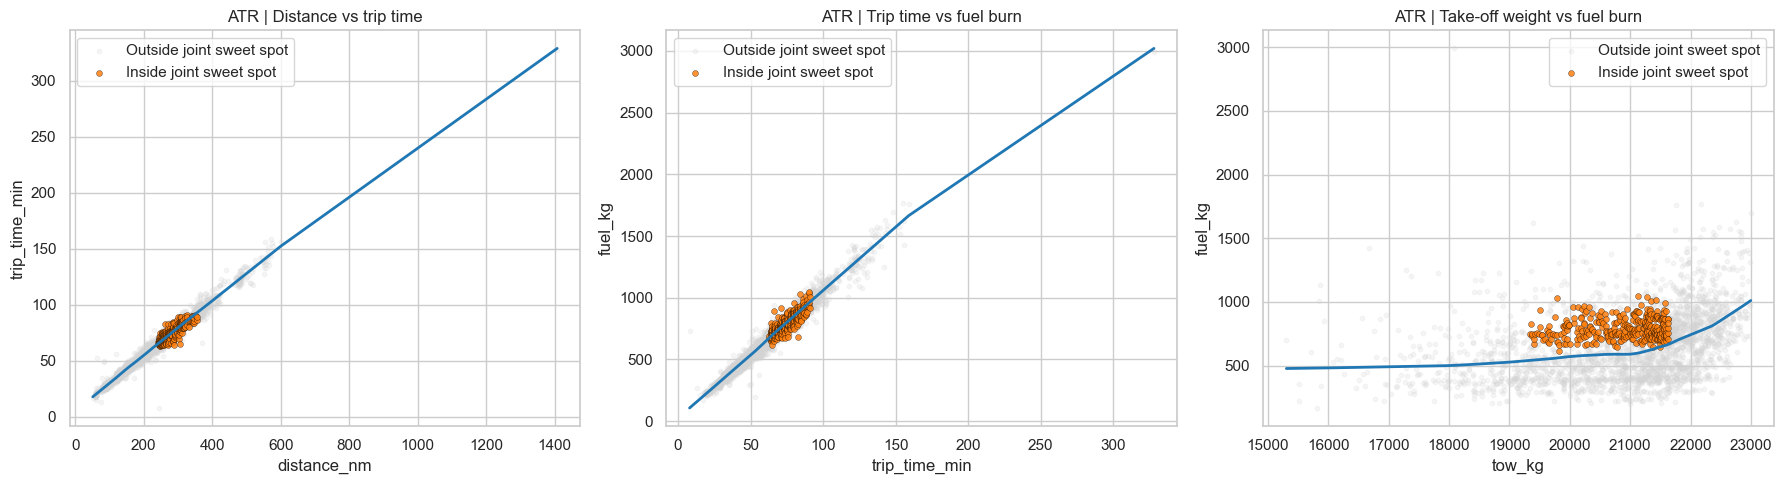

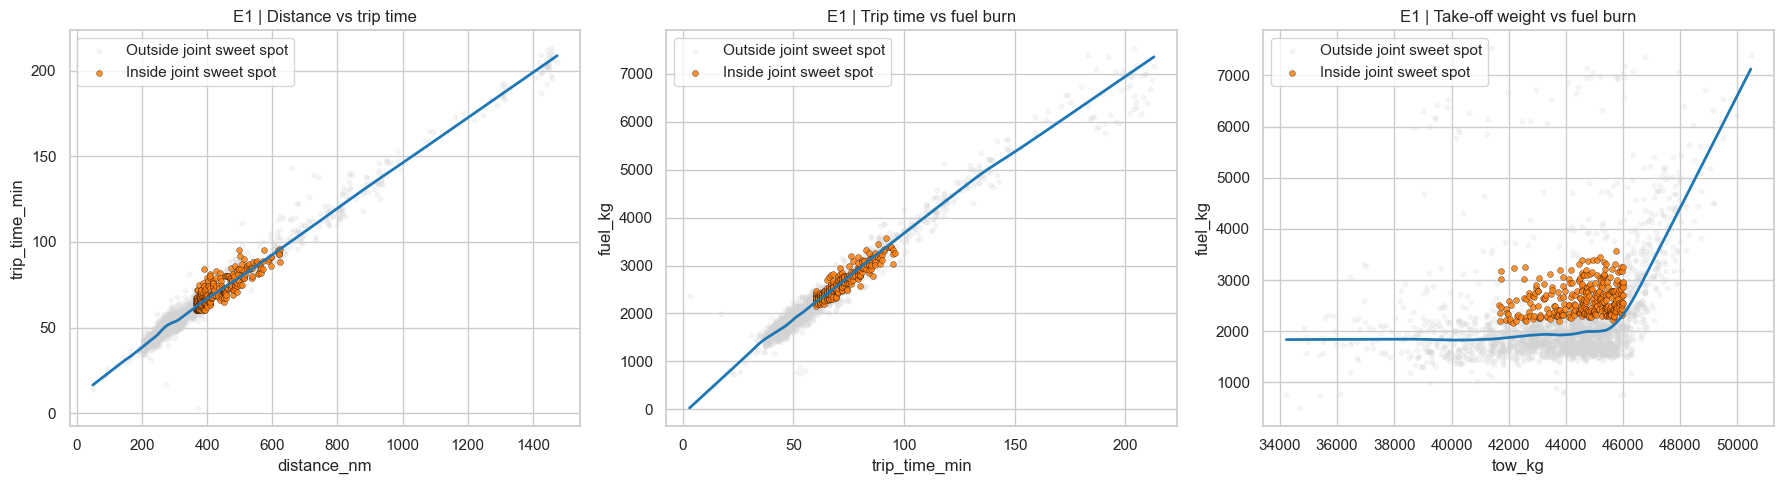

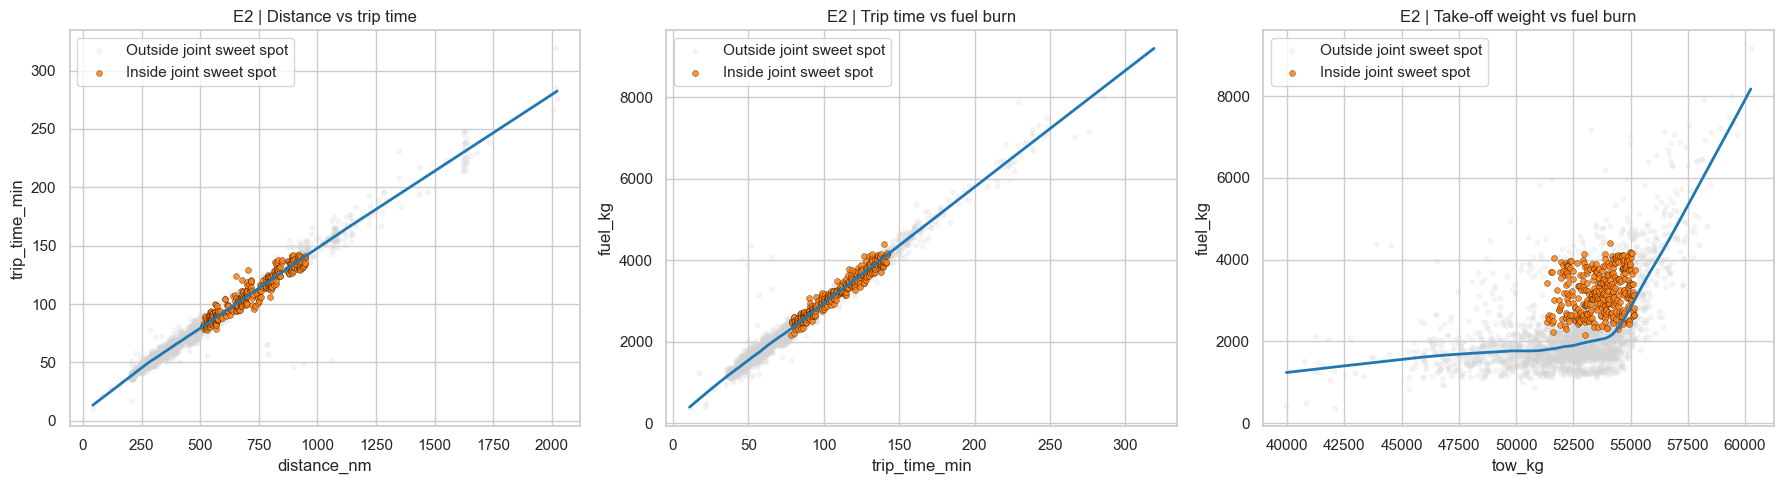

A320: 11.0% of flights in joint sweet spot
A321: 6.5% of flights in joint sweet spot
ATR: 13.9% of flights in joint sweet spot
E1: 13.0% of flights in joint sweet spot
E2: 12.5% of flights in joint sweet spot


In [49]:
joint_plot_base = sweet_spot_joint.dropna(subset=plot_vars + ["Equipment"]).copy()

def plot_section3_highlight_sweetspot(data, equipment, pairs, sample_size=2500, frac=0.28):
    g = data[data["Equipment"] == equipment].copy()
    if len(g) > sample_size:
        g = g.sample(sample_size, random_state=RANDOM_STATE)

    fig, axes = plt.subplots(1, len(pairs), figsize=(18, 5))

    for ax, (x, y, title) in zip(axes, pairs):
        g2 = g[[x, y, "is_joint_sweet_spot"]].dropna().sort_values(x)

        outside = g2[~g2["is_joint_sweet_spot"]]
        inside = g2[g2["is_joint_sweet_spot"]]

        if len(outside) > 0:
            ax.scatter(
                outside[x], outside[y],
                s=10, alpha=0.20, color="lightgray",
                label="Outside joint sweet spot"
            )

        if len(inside) > 0:
            ax.scatter(
                inside[x], inside[y],
                s=18, alpha=0.85, color="tab:orange",
                edgecolor="black", linewidth=0.25,
                label="Inside joint sweet spot"
            )

        if len(g2) >= 50 and g2[x].nunique() > 10:
            smoothed = lowess(g2[y], g2[x], frac=frac, return_sorted=True)
            ax.plot(smoothed[:, 0], smoothed[:, 1], linewidth=2, color="tab:blue")

        ax.set_title(f"{equipment} | {title}")
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.legend()

    plt.tight_layout()
    plt.show()


for equipment in sorted(joint_plot_base["Equipment"].unique()):
    plot_section3_highlight_sweetspot(
        joint_plot_base,
        equipment,
        section3_pairs,
        sample_size=2500,
        frac=0.28
    )

#print percentage of flights in the joint sweet spot for each equipment type
for equipment, g in sweet_spot_joint.groupby("Equipment"):
    total_flights = len(g)
    joint_sweet_spot_flights = g["is_joint_sweet_spot"].sum()
    percentage = (joint_sweet_spot_flights / total_flights * 100) if total_flights > 0 else 0
    print(f"{equipment}: {percentage:.1f}% of flights in joint sweet spot")


### Analysing the sweetspot

These charts preserve the **full mission distribution** of each aircraft family while making the joint sweet spot immediately visible.

This makes it easier to see whether the sweet spot is central to the aircraft's normal mission profile or whether it is concentrated in a narrower corner of the observed operation.


## 4. Behavior-based clustering after the scatter-plot analysis

This section builds groups using the operating behavior that emerged in the scatter plots and sweet-spot analysis: typical mission profile, sweet-spot mission profile, fuel intensity, and the observed fuel slope versus distance. The result is a grouping that reflects how each aircraft actually behaves on the network.

In [50]:
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import pdist, squareform

section4_base = optimal_base.copy()
section4_base["fuel_per_ton_nm"] = (
    section4_base["fuel_kg"] / (section4_base["tow_kg"] / 1000) / section4_base["distance_nm"]
)

behavior_rows = []

for equipment, g in section4_base.groupby("Equipment"):
    best = g[g["fuel_per_nm"] <= g["fuel_per_nm"].quantile(0.25)].copy()

    distance_model = LinearRegression().fit(g[["distance_nm"]], g["fuel_kg"])
    time_model = LinearRegression().fit(g[["trip_time_min"]], g["fuel_kg"])

    behavior_rows.append({
        "Equipment": equipment,
        "flights": len(g),
        "distance_median_nm": g["distance_nm"].median(),
        "trip_time_median_min": g["trip_time_min"].median(),
        "tow_median_kg": g["tow_kg"].median(),
        "fuel_median_kg": g["fuel_kg"].median(),
        "fuel_per_nm_median": g["fuel_per_nm"].median(),
        "fuel_per_ton_nm_median": g["fuel_per_ton_nm"].median(),
        "sweet_distance_median_nm": best["distance_nm"].median(),
        "sweet_trip_time_median_min": best["trip_time_min"].median(),
        "sweet_tow_median_kg": best["tow_kg"].median(),
        "sweet_fuel_per_nm": best["fuel_per_nm"].median(),
        "fuel_vs_distance_nm_slope": distance_model.coef_[0],
        "fuel_vs_trip_time_min_slope": time_model.coef_[0],
        "fuel_vs_distance_r2": distance_model.score(g[["distance_nm"]], g["fuel_kg"]),
        "fuel_vs_trip_time_r2": time_model.score(g[["trip_time_min"]], g["fuel_kg"])
    })

behavior_profile = (
    pd.DataFrame(behavior_rows)
    .set_index("Equipment")
    .sort_values(["sweet_distance_median_nm", "sweet_fuel_per_nm"])
)

behavior_profile.round(2)

,flights,distance_median_nm,trip_time_median_min,tow_median_kg,fuel_median_kg,fuel_per_nm_median,fuel_per_ton_nm_median,sweet_distance_median_nm,sweet_trip_time_median_min,sweet_tow_median_kg,sweet_fuel_per_nm,fuel_vs_distance_nm_slope,fuel_vs_trip_time_min_slope,fuel_vs_distance_r2,fuel_vs_trip_time_r2
Equipment,,,,,,,,,,,,,,,
ATR,78520,231.00,62.00,"21,225.00",660.00,2.96,0.14,288.00,75.00,"20,639.00",2.69,2.57,10.32,0.96,0.95
E1,44816,295.60,53.00,"44,428.50","1,994.00",6.68,0.15,465.60,73.00,"44,283.00",5.80,4.60,33.86,0.95,0.97
E2,50309,382.80,64.00,"52,743.00","1,977.00",4.98,0.10,790.00,116.00,"53,399.00",4.36,3.89,28.14,0.97,0.97
A320,100893,889.20,128.00,"66,644.00","4,529.00",5.38,0.08,"1,033.00",145.00,"65,568.50",4.88,4.76,35.80,0.96,0.98
A321,13794,"1,170.40",167.00,"80,116.50","7,116.50",6.01,0.07,"1,167.10",160.00,"75,770.00",5.50,5.81,44.60,0.89,0.92


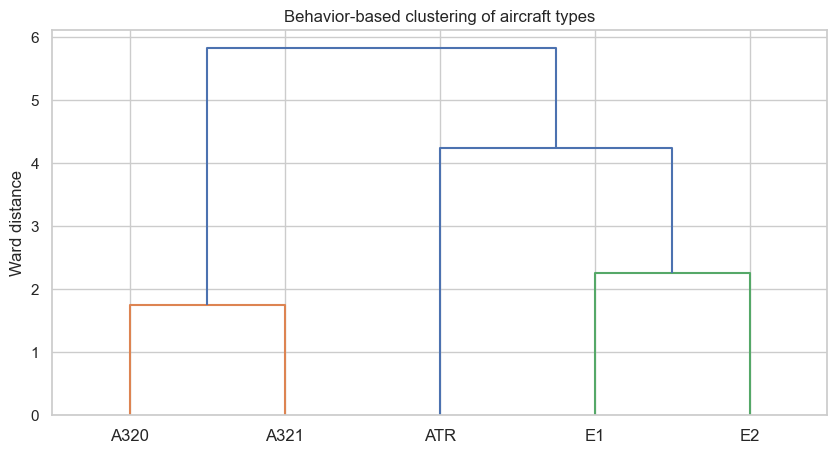

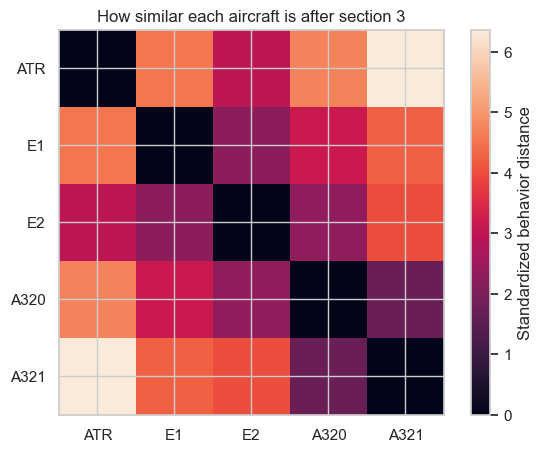

,operational_group,distance_median_nm,sweet_distance_median_nm,fuel_per_nm_median,sweet_fuel_per_nm,fuel_vs_distance_nm_slope
Equipment,,,,,,
A320,Medium to long-haul narrowbody missions,889.20,"1,033.00",5.38,4.88,4.76
A321,Medium to long-haul narrowbody missions,"1,170.40","1,167.10",6.01,5.50,5.81
E1,Short to medium regional jet missions,295.60,465.60,6.68,5.80,4.60
E2,Short to medium regional jet missions,382.80,790.00,4.98,4.36,3.89
ATR,Short-haul turboprop missions,231.00,288.00,2.96,2.69,2.57


In [51]:
cluster_features = behavior_profile[[
    "distance_median_nm",
    "trip_time_median_min",
    "fuel_per_nm_median",
    "sweet_distance_median_nm",
    "sweet_fuel_per_nm",
    "fuel_vs_distance_nm_slope"
]]

scaler = StandardScaler()
X = scaler.fit_transform(cluster_features)

behavior_distance_map = pd.DataFrame(
    squareform(pdist(X)),
    index=cluster_features.index,
    columns=cluster_features.index
)

Z = linkage(X, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=cluster_features.index.tolist())
plt.title("Behavior-based clustering of aircraft types")
plt.ylabel("Ward distance")
plt.show()

plt.figure(figsize=(7, 5))
plt.imshow(behavior_distance_map)
plt.xticks(range(len(behavior_distance_map.columns)), behavior_distance_map.columns)
plt.yticks(range(len(behavior_distance_map.index)), behavior_distance_map.index)
plt.colorbar(label="Standardized behavior distance")
plt.title("How similar each aircraft is after section 3")
plt.show()

chosen_k = 3
cluster_labels = fcluster(Z, chosen_k, criterion="maxclust")

clustered_behavior = behavior_profile.copy()
clustered_behavior["cluster_id"] = cluster_labels

cluster_order = (
    clustered_behavior.groupby("cluster_id")["sweet_distance_median_nm"]
    .median()
    .sort_values()
    .index
    .tolist()
)

cluster_name_map = {
    cluster_order[0]: "Short-haul turboprop missions",
    cluster_order[1]: "Short to medium regional jet missions",
    cluster_order[2]: "Medium to long-haul narrowbody missions"
}

clustered_behavior["operational_group"] = clustered_behavior["cluster_id"].map(cluster_name_map)
clustered_behavior = clustered_behavior.sort_values(["cluster_id", "sweet_distance_median_nm"])

clustered_behavior[[
    "operational_group",
    "distance_median_nm",
    "sweet_distance_median_nm",
    "fuel_per_nm_median",
    "sweet_fuel_per_nm",
    "fuel_vs_distance_nm_slope"
]].round(2)

### What this shows about each equipment behaviour

Now the groups are anchored in observed operating behavior. ATR stays isolated because it has a very different fuel curve and mission length. E1 and E2 cluster together as the regional jet family, but E2 remains visibly more efficient inside the shared short and medium-haul space. A320 and A321 stay together as the larger narrowbody family because their sweet spots and fuel slopes are much closer to each other than to the regional fleet.

## 5. Route interchangeability inside the sweet spots

The next step is to test interchangeability only where there is direct evidence in the data. The screen below keeps routes where at least two aircraft already appear inside their own joint sweet spots. This is a conservative way to look for fuel-saving swaps because it avoids comparing aircraft on missions that are outside their efficient operating windows.

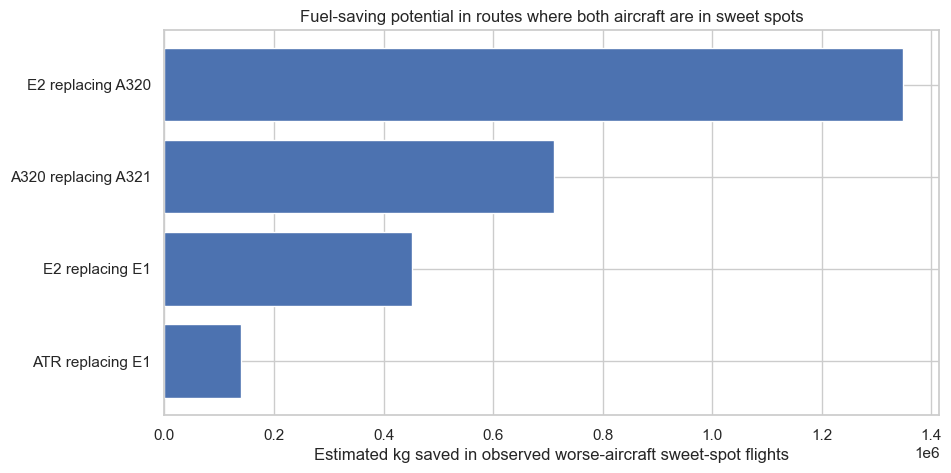

,better_equipment,worse_equipment,candidate_routes,observed_worse_sweet_flights,median_savings_pct,total_estimated_kg_saved,swap_direction
0,E2,A320,10,1700,16.30,"1,347,556.00",E2 replacing A320
1,A320,A321,2,778,14.00,"710,907.50",A320 replacing A321
2,E2,E1,12,1078,17.00,"451,583.50",E2 replacing E1
3,ATR,E1,1,99,55.10,"139,986.00",ATR replacing E1


,route,better_equipment,worse_equipment,median_distance_nm,better_sweet_flights,worse_sweet_flights,estimated_kg_saved_per_flight,estimated_savings_pct,estimated_total_kg_saved_on_observed_worse_sweet_flights
23,VCP-REC,A320,A321,"1,167.50",204,521,906.00,14.00,"472,026.00"
1,BEL-REC,E2,A320,918.00,23,617,726.00,15.80,"447,942.00"
9,GRU-REC,A320,A321,"1,158.40",206,257,929.50,14.10,"238,881.50"
15,REC-CNF,E2,A320,897.20,29,182,885.50,16.30,"161,161.00"
8,FOR-REC,ATR,E1,358.00,31,99,"1,414.00",55.10,"139,986.00"
10,JPA-CNF,E2,A320,939.30,21,159,879.00,17.10,"139,761.00"
11,MAB-CNF,E2,A320,919.40,120,160,783.50,16.00,"125,360.00"
4,CKS-CNF,E2,A320,905.90,73,136,831.50,16.40,"113,084.00"
0,AJU-VCP,E2,A320,947.50,26,116,813.50,15.80,"94,366.00"
18,THE-CNF,E2,A320,905.30,56,119,748.00,15.10,"89,012.00"


In [52]:
route_sweet = (
    sweet_spot_joint[sweet_spot_joint["is_joint_sweet_spot"]]
    .groupby(["route", "Equipment"])
    .agg(
        sweet_flights=("FlightNumber", "count"),
        median_distance_nm=("distance_nm", "median"),
        median_trip_time_min=("trip_time_min", "median"),
        median_tow_kg=("tow_kg", "median"),
        median_fuel_kg=("fuel_kg", "median"),
        median_fuel_per_nm=("fuel_per_nm", "median")
    )
    .reset_index()
)

route_sweet = route_sweet[route_sweet["sweet_flights"] >= 20].copy()

pair_rows = []

for route, g in route_sweet.groupby("route"):
    if g["Equipment"].nunique() < 2:
        continue

    rows = g.to_dict("records")

    for i in range(len(rows)):
        for j in range(i + 1, len(rows)):
            a, b = rows[i], rows[j]
            better, worse = (a, b) if a["median_fuel_per_nm"] <= b["median_fuel_per_nm"] else (b, a)

            pair_rows.append({
                "route": route,
                "better_equipment": better["Equipment"],
                "worse_equipment": worse["Equipment"],
                "better_sweet_flights": better["sweet_flights"],
                "worse_sweet_flights": worse["sweet_flights"],
                "median_distance_nm": np.median([better["median_distance_nm"], worse["median_distance_nm"]]),
                "better_fuel_per_nm": better["median_fuel_per_nm"],
                "worse_fuel_per_nm": worse["median_fuel_per_nm"],
                "estimated_kg_saved_per_nm": worse["median_fuel_per_nm"] - better["median_fuel_per_nm"],
                "estimated_kg_saved_per_flight": worse["median_fuel_kg"] - better["median_fuel_kg"]
            })

route_interchange_candidates = pd.DataFrame(pair_rows)

route_interchange_candidates["estimated_savings_pct"] = (
    route_interchange_candidates["estimated_kg_saved_per_nm"]
    / route_interchange_candidates["worse_fuel_per_nm"]
    * 100
)

route_interchange_candidates["estimated_total_kg_saved_on_observed_worse_sweet_flights"] = (
    route_interchange_candidates["estimated_kg_saved_per_flight"]
    * route_interchange_candidates["worse_sweet_flights"]
)

route_interchange_candidates = route_interchange_candidates.sort_values(
    ["estimated_total_kg_saved_on_observed_worse_sweet_flights", "estimated_savings_pct"],
    ascending=[False, False]
)

swap_summary = (
    route_interchange_candidates
    .groupby(["better_equipment", "worse_equipment"])
    .agg(
        candidate_routes=("route", "nunique"),
        observed_worse_sweet_flights=("worse_sweet_flights", "sum"),
        median_savings_pct=("estimated_savings_pct", "median"),
        total_estimated_kg_saved=("estimated_total_kg_saved_on_observed_worse_sweet_flights", "sum")
    )
    .sort_values("total_estimated_kg_saved", ascending=False)
    .reset_index()
)

swap_summary["swap_direction"] = (
    swap_summary["better_equipment"] + " replacing " + swap_summary["worse_equipment"]
)

plt.figure(figsize=(10, 5))
plt.barh(
    swap_summary["swap_direction"][::-1],
    swap_summary["total_estimated_kg_saved"][::-1]
)
plt.title("Fuel-saving potential in routes where both aircraft are in sweet spots")
plt.xlabel("Estimated kg saved in observed worse-aircraft sweet-spot flights")
plt.ylabel("")
plt.show()

top_route_candidates = route_interchange_candidates[[
    "route",
    "better_equipment",
    "worse_equipment",
    "median_distance_nm",
    "better_sweet_flights",
    "worse_sweet_flights",
    "estimated_kg_saved_per_flight",
    "estimated_savings_pct",
    "estimated_total_kg_saved_on_observed_worse_sweet_flights"
]].head(15)

display(swap_summary.round(1))
display(top_route_candidates.round(1))

### What this suggests

Inside the overlap routes, the strongest repeated pattern is E2 outperforming both E1 and A320 on a wide set of short and medium-haul missions, especially around the 500 to 950 NM range. A320 also looks more fuel-efficient than A321 on the long Recife overlaps in this sample. ATR can beat E1 on at least one short route, but that comparison should be treated carefully because seat capacity, payload, and airport constraints are not being accounted for. This section is a fuel-only screen, not a final fleet assignment recommendation.

## 6. Capacity-fit substitution using seats as a demand proxy

Fuel savings alone are not enough to recommend aircraft substitution. A smaller aircraft may burn less fuel per flight, but still fail to cover the same demand if its seat capacity is much lower.

This section adds a **seat-capacity screen** to the route interchangeability logic from section 5.

Important limitation:
- The sample has **no passenger demand, load factor, or revenue data**
- So this is **not a true demand model**
- Instead, we use **typical seat capacity by aircraft family** as a proxy for the route's capacity requirement

The logic is conservative:
1. start from the fuel-saving swap candidates already observed inside the sweet spots
2. attach an assumed seat capacity to each aircraft family
3. estimate how many flights of the better aircraft would be needed to deliver the same number of seats as the worse aircraft on the observed sweet-spot flights
4. compare total fuel under an **equal-seat-supply** assumption

This answers a more realistic question:

**If the airline wanted to preserve approximately the same seat supply on that route, would the more fuel-efficient aircraft still save fuel?**

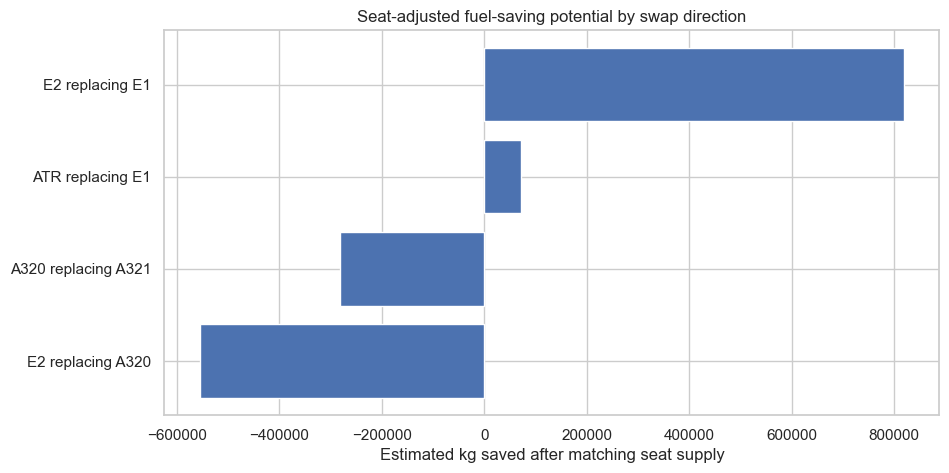

,better_equipment,worse_equipment,candidate_routes,routes_passing_capacity_screen,median_equal_seat_supply_savings_pct,total_equal_seat_supply_kg_saved,median_extra_flights_needed_pct,swap_direction
3,E2,E1,12,12,26.50,"819,861.30",0.00,E2 replacing E1
1,ATR,E1,1,0,30.00,"71,760.90",68.60,ATR replacing E1
0,A320,A321,2,0,-5.50,"-281,709.40",23.00,A320 replacing A321
2,E2,A320,10,0,-5.70,"-555,638.80",27.90,E2 replacing A320


,route,better_equipment,worse_equipment,better_assumed_seats,worse_assumed_seats,capacity_fit,additional_flights_needed_pct,per_seat_nm_improvement_pct,equal_seat_supply_savings_pct,equal_seat_supply_kg_saved,capacity_screen_pass
16,BSB-VCP,E2,E1,136,118,close capacity fit,0.00,29.00,19.00,"123,086.40",True
11,BYO-VCP,E2,E1,136,118,close capacity fit,0.00,29.40,30.80,"115,349.20",True
12,SSA-CNF,E2,E1,136,118,close capacity fit,0.00,27.90,27.70,"112,431.10",True
13,THE-REC,E2,E1,136,118,close capacity fit,0.00,29.70,29.60,"98,294.00",True
15,CNF-SSA,E2,E1,136,118,close capacity fit,0.00,30.10,30.30,"76,392.50",True
18,ROO-VCP,E2,E1,136,118,close capacity fit,0.00,26.90,26.30,"67,952.90",True
19,PMW-CNF,E2,E1,136,118,close capacity fit,0.00,28.50,27.80,"52,671.40",True
20,POA-VCP,E2,E1,136,118,close capacity fit,0.00,27.50,24.70,"48,025.20",True
22,VCP-POA,E2,E1,136,118,close capacity fit,0.00,27.00,20.40,"33,163.80",True
21,VCP-ROO,E2,E1,136,118,close capacity fit,0.00,27.00,26.70,"32,453.80",True


In [53]:
seat_assumptions = pd.DataFrame({
    "Equipment": ["ATR", "E1", "E2", "A320", "A321"],
    "assumed_seats": [70, 118, 136, 174, 214]
})

route_capacity = route_sweet.merge(seat_assumptions, on="Equipment", how="left").copy()

capacity_candidates = (
    route_interchange_candidates
    .merge(
        route_capacity[["route", "Equipment", "assumed_seats", "median_fuel_kg", "median_fuel_per_nm"]],
        left_on=["route", "better_equipment"],
        right_on=["route", "Equipment"],
        how="left"
    )
    .rename(columns={
        "assumed_seats": "better_assumed_seats",
        "median_fuel_kg": "better_median_fuel_kg",
        "median_fuel_per_nm": "better_route_fuel_per_nm"
    })
    .drop(columns=["Equipment"])
    .merge(
        route_capacity[["route", "Equipment", "assumed_seats", "median_fuel_kg", "median_fuel_per_nm"]],
        left_on=["route", "worse_equipment"],
        right_on=["route", "Equipment"],
        how="left"
    )
    .rename(columns={
        "assumed_seats": "worse_assumed_seats",
        "median_fuel_kg": "worse_median_fuel_kg",
        "median_fuel_per_nm": "worse_route_fuel_per_nm"
    })
    .drop(columns=["Equipment"])
    .copy()
)

capacity_candidates["seat_gap"] = (
    capacity_candidates["better_assumed_seats"] - capacity_candidates["worse_assumed_seats"]
)
capacity_candidates["seat_gap_pct"] = (
    capacity_candidates["seat_gap"] / capacity_candidates["worse_assumed_seats"] * 100
)

capacity_candidates["observed_worse_seat_supply"] = (
    capacity_candidates["worse_sweet_flights"] * capacity_candidates["worse_assumed_seats"]
)

capacity_candidates["better_flights_needed_for_same_seat_supply"] = (
    capacity_candidates["observed_worse_seat_supply"] / capacity_candidates["better_assumed_seats"]
)

capacity_candidates["better_vs_worse_flight_ratio_for_same_seat_supply"] = (
    capacity_candidates["better_flights_needed_for_same_seat_supply"]
    / capacity_candidates["worse_sweet_flights"]
)

capacity_candidates["additional_flights_needed_pct"] = np.where(
    capacity_candidates["better_vs_worse_flight_ratio_for_same_seat_supply"] > 1,
    (capacity_candidates["better_vs_worse_flight_ratio_for_same_seat_supply"] - 1) * 100,
    0
)

capacity_candidates["observed_total_fuel_worse"] = (
    capacity_candidates["worse_sweet_flights"] * capacity_candidates["worse_median_fuel_kg"]
)

capacity_candidates["equal_seat_supply_total_fuel_better"] = (
    capacity_candidates["better_flights_needed_for_same_seat_supply"]
    * capacity_candidates["better_median_fuel_kg"]
)

capacity_candidates["equal_seat_supply_kg_saved"] = (
    capacity_candidates["observed_total_fuel_worse"]
    - capacity_candidates["equal_seat_supply_total_fuel_better"]
)

capacity_candidates["equal_seat_supply_savings_pct"] = (
    capacity_candidates["equal_seat_supply_kg_saved"]
    / capacity_candidates["observed_total_fuel_worse"]
    * 100
)

capacity_candidates["better_fuel_per_seat_nm"] = (
    capacity_candidates["better_route_fuel_per_nm"] / capacity_candidates["better_assumed_seats"]
)
capacity_candidates["worse_fuel_per_seat_nm"] = (
    capacity_candidates["worse_route_fuel_per_nm"] / capacity_candidates["worse_assumed_seats"]
)

capacity_candidates["per_seat_nm_improvement_pct"] = (
    (capacity_candidates["worse_fuel_per_seat_nm"] - capacity_candidates["better_fuel_per_seat_nm"])
    / capacity_candidates["worse_fuel_per_seat_nm"]
    * 100
)

capacity_candidates["capacity_fit"] = np.select(
    [
        capacity_candidates["seat_gap_pct"].abs() <= 10,
        capacity_candidates["seat_gap_pct"].abs() <= 20,
        (capacity_candidates["seat_gap_pct"] < -20)
        & (capacity_candidates["additional_flights_needed_pct"] <= 25),
        capacity_candidates["seat_gap_pct"] > 20
    ],
    [
        "direct seat-capacity fit",
        "close capacity fit",
        "smaller aircraft, needs some extra frequency",
        "larger aircraft, risk of over-capacity"
    ],
    default="smaller aircraft, large frequency increase needed"
)

capacity_candidates["capacity_screen_pass"] = (
    capacity_candidates["equal_seat_supply_kg_saved"] > 0
) & (
    capacity_candidates["capacity_fit"].isin([
        "direct seat-capacity fit",
        "close capacity fit",
        "smaller aircraft, needs some extra frequency"
    ])
)

capacity_candidates = capacity_candidates.sort_values(
    ["capacity_screen_pass", "equal_seat_supply_kg_saved", "equal_seat_supply_savings_pct"],
    ascending=[False, False, False]
)

capacity_swap_summary = (
    capacity_candidates
    .groupby(["better_equipment", "worse_equipment"])
    .agg(
        candidate_routes=("route", "nunique"),
        routes_passing_capacity_screen=("capacity_screen_pass", "sum"),
        median_equal_seat_supply_savings_pct=("equal_seat_supply_savings_pct", "median"),
        total_equal_seat_supply_kg_saved=("equal_seat_supply_kg_saved", "sum"),
        median_extra_flights_needed_pct=("additional_flights_needed_pct", "median")
    )
    .reset_index()
    .sort_values("total_equal_seat_supply_kg_saved", ascending=False)
)

capacity_swap_summary["swap_direction"] = (
    capacity_swap_summary["better_equipment"] + " replacing " + capacity_swap_summary["worse_equipment"]
)

plt.figure(figsize=(10, 5))
plot_df = capacity_swap_summary.sort_values("total_equal_seat_supply_kg_saved", ascending=True)
plt.barh(plot_df["swap_direction"], plot_df["total_equal_seat_supply_kg_saved"])
plt.title("Seat-adjusted fuel-saving potential by swap direction")
plt.xlabel("Estimated kg saved after matching seat supply")
plt.ylabel("")
plt.show()

top_capacity_candidates = capacity_candidates[[
    "route",
    "better_equipment",
    "worse_equipment",
    "better_assumed_seats",
    "worse_assumed_seats",
    "capacity_fit",
    "additional_flights_needed_pct",
    "per_seat_nm_improvement_pct",
    "equal_seat_supply_savings_pct",
    "equal_seat_supply_kg_saved",
    "capacity_screen_pass"
]].head(20)

display(capacity_swap_summary.round(1))
display(top_capacity_candidates.round(1))

### How to interpret this seat-based screen

A swap is strongest when four things are true at the same time:
- the candidate route already shows both aircraft inside their own sweet spots
- the better aircraft burns less fuel per flight
- the better aircraft also improves **fuel per seat nautical mile**
- the same total seat supply can be preserved with little or no extra frequency

This makes the result more realistic than a simple fuel-per-flight comparison, still, this remains a proxy analysis.

## 7. Other ways to make the routes more fuel efficient

The route-swap logic is only one lever. Based on this sample, the next operational ideas to test are:

1. **Gauge by departure wave, not just by route**  
   Some routes may justify a larger aircraft only in peak banks. Off-peak frequencies may be better served by E2 or E1 if demand is lower.

2. **Prefer aircraft closer to their natural mission length**  
   The sweet-spot analysis suggests ATR works best on short sectors, E2 is strong in the short-to-medium jet range, A320 on medium sectors, and A321 where demand is dense enough to absorb the extra seats.

3. **Optimize for fuel per seat-NM, not only fuel per flight**  
   A smaller aircraft can look better per flight but lose its advantage if too many extra flights are needed to preserve capacity.

4. **Reduce unnecessary take-off weight**  
   The scatter plots show weight is strongly associated with fuel burn. Better baggage, cargo, tankering, and reserve-fuel discipline can reduce fuel on the same route without changing aircraft.

5. **Cut taxi, holding, and ground inefficiencies**  
   If a route often leaves in congested banks, the schedule itself may be creating avoidable fuel burn before take-off and during arrival sequencing.

6. **Use dynamic up-gauging and down-gauging instead of static route assignment**  
   The same city-pair can need different aircraft by weekday, season, or holiday period.

7. **Investigate the tail routes with poor fuel-per-NM performance inside the same aircraft family**  
   Those may reveal operational inefficiencies, weather exposure, payload mix, or network-planning mismatches.